# Reports: Statistics of parts in ProdDB

Currently just collecting stats via manufacturer, location etc. based on parts details, later: track also the quality flags of each part (once defined and agreed on with coordinators + users how to record them)

In [82]:
# standard package imports and default ATLAS style
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import mplhep as hep

# ATLAS plot style
hep.style.use("ATLAS1")

from cycler import cycler

# Color wheel from https://arxiv.org/pdf/2107.02270 Table 1, 10 color palette
# This is the color wheel recommended for plots that require a large number
# of colors that would not be satisfied by the below palette
color_sequence1 = [
    "#3f90da",
    "#ffa90e",
    "#bd1f01",
    "#94a4a2",
    "#832db6",
    "#a96b59",
    "#e76300",
    "#b9ac70",
    "#717581",
    "#92dadd",
]

# Color wheel based on internal discussions of optimal
# colors for visibility, accounting for color vision deficiency
# The recommendation for signal is the first color (Vermilion)
# For large signals, ROOT.kWhite / '#ffffff' is also an option
color_sequence2 = [
    "#d55e00",
    "#56b4e9",
    "#e69f00",
    "#f0e442",
    "#009e73",
    "#cc79a7",
    "#0072b2",
]

combination_color_sequence = color_sequence1 + color_sequence2

colors_tab20c = mpl.color_sequences['tab20c']

plt.rcParams['axes.axisbelow'] = True
#plt.rcParams['axes.prop_cycle'] = cycler("color", combination_color_sequence)
plt.rcParams['axes.prop_cycle'] = cycler("color", colors_tab20c + combination_color_sequence)


In [2]:
from collections import Counter

In [3]:
from datetime import datetime

In [4]:
import api, data, util

In [70]:
categories = ['Sensor', 'Wafer', 'ASIC', 'Hybrid', 'Module Flex', 'Module', 'Support Unit', 'Detector Unit', 'PEB', 'PEB_MUX64', 'Flex Tail', 'HV_PS', 'HV_module']

In [71]:
# first of all, get the relevant parts (by KoP to not kill the pod)
# standard: only non-deleted parts, only parts without full attributes
parts_in_categories = {c:util.get_relevant_parts(c)[0] for c in categories}

In [10]:
# for slots it simply won't work, good to know that just 8k parts will crash that endpoint directly
slots, last_responseText = util.get_relevant_parts('Slot')

HTTPError: [Errno Http Error:] 502 Server Error: Bad Gateway for url: https://hgtddb-api.web.cern.ch/hgtddb/partattributelistbykop/2412/

In [72]:
# in the relevant parts list, grab those fulfilling a certain criterion or directly histogram by that attribute
# we only need to count by the feature, so first we need to flatten to get those features
interesting_features = ['Location', 'Manufacturer','Uploaded by','Uploaded in YYYY-MM']
print('Creating overview for', interesting_features)

Creating overview for ['Location', 'Manufacturer', 'Uploaded by', 'Uploaded in YYYY-MM']


In [73]:
interesting_data_all_cats = {c:dict() for c in categories}
for c in categories:
    interesting_data_per_c = {f : [] for f in interesting_features}
    for p in parts_in_categories[c]:
        if str(p['serial_number'][:3]) != '20W':
            continue
        if 'Location' in interesting_features:
            interesting_data_per_c['Location'].append(p['location']['location_name'])
        if 'Manufacturer' in interesting_features:
            interesting_data_per_c['Manufacturer'].append(p['manufacturer']['manufacturer_name'])
        if 'Uploaded by' in interesting_features:
            interesting_data_per_c['Uploaded by'].append(p['record_insertion_user'])
        if 'Uploaded in YYYY-MM' in interesting_features:
            time = p['record_insertion_time']
            if time == None:
                interesting_data_per_c['Uploaded in YYYY-MM'].append('Unknown')
            else:
                interesting_data_per_c['Uploaded in YYYY-MM'].append(p['record_insertion_time'][:7])
    interesting_data_all_cats[c] = interesting_data_per_c

In [74]:
interesting_data_all_cats

{'Sensor': {'Location': ['HMC',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP-IME',
   'IHEP

In [75]:
multi_count_dict = {c:{f:dict() for f in interesting_features} for c in categories}
for c in categories:
    for f in interesting_features:
        multi_count_dict[c][f] = dict(Counter(interesting_data_all_cats[c][f]).items())

In [76]:
multi_count_dict

{'Sensor': {'Location': {'HMC': 1,
   'IHEP-IME': 2496,
   'Taipei': 52,
   'USTC': 988,
   'IHEP': 626},
  'Manufacturer': {'IFAE': 1,
   'IHEP-IME': 2654,
   'Academia Sinica': 52,
   'USTC-IME': 1456},
  'Uploaded by': {'mimran': 1,
   'tianyuan': 1508,
   'yunju': 52,
   'ATLAS_HGTD_PROD': 2602},
  'Uploaded in YYYY-MM': {'Unknown': 1,
   '2025-05': 1508,
   '2025-03': 52,
   '2024-09': 988,
   '2024-08': 520,
   '2024-05': 468,
   '2024-04': 104,
   '2024-03': 468,
   '2024-02': 52,
   '2024-01': 2}},
 'Wafer': {'Location': {'IHEP-IME': 151,
   'CDF': 1,
   'USTC': 18,
   'IHEP': 22,
   'CERN': 2},
  'Manufacturer': {'IHEP-IME': 164,
   'TSMC': 1,
   'USTC-IME': 27,
   'Academia Sinica': 1,
   'IFAE': 1},
  'Uploaded by': {'tianyuan': 29, 'weiyi': 104, 'ATLAS_HGTD_PROD': 61},
  'Uploaded in YYYY-MM': {'2025-05': 133,
   '2025-01': 1,
   '2024-09': 18,
   '2024-08': 10,
   '2024-05': 8,
   '2024-04': 2,
   '2024-03': 9,
   '2024-02': 2,
   '2024-01': 9,
   '2023-12': 1,
   '2023-08

In [104]:
import json
with open('report_stats.json', 'w') as rep_data_f:
    json.dump(multi_count_dict, rep_data_f)

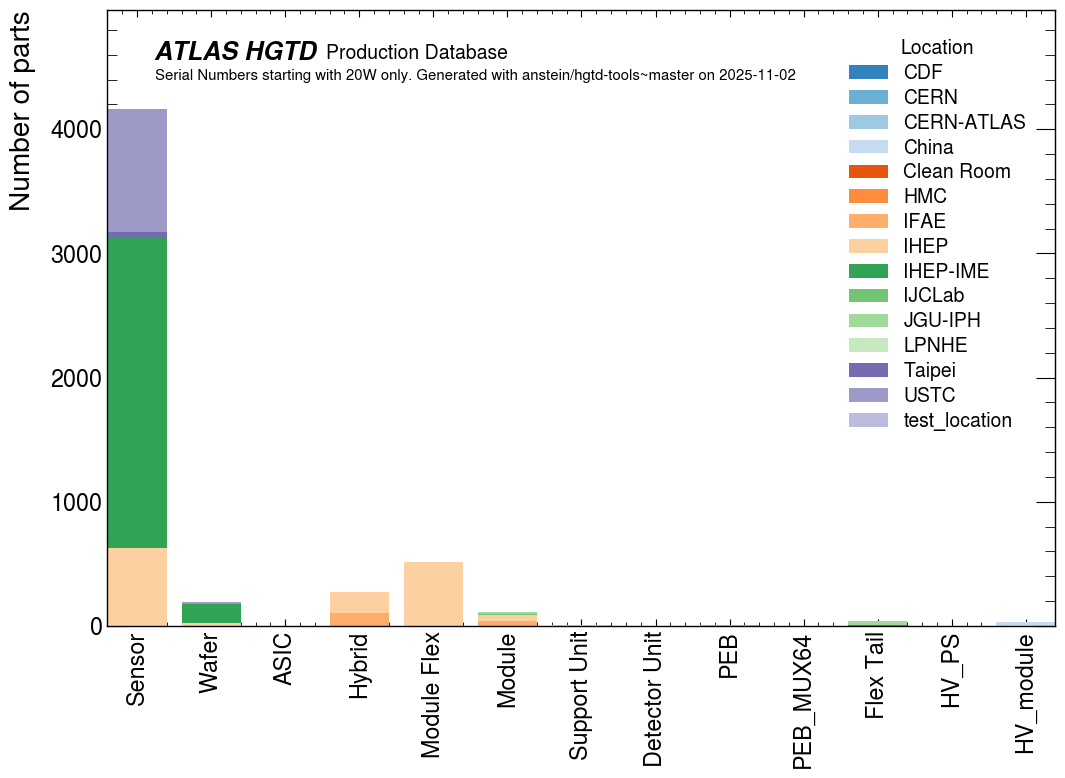

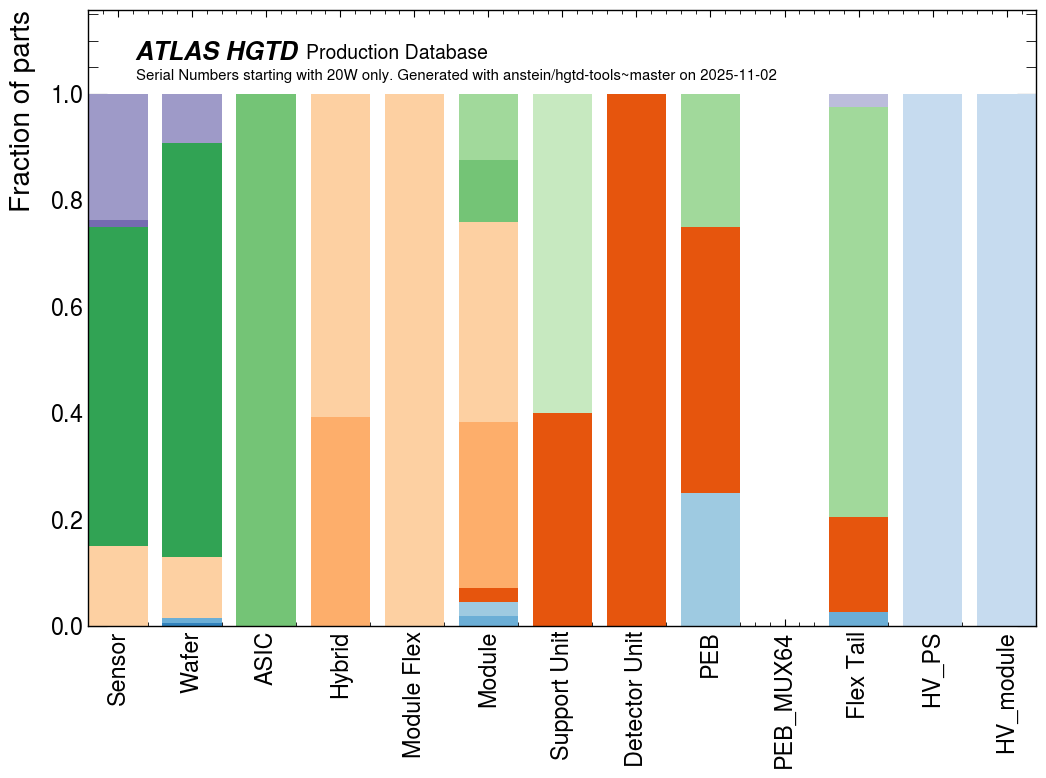

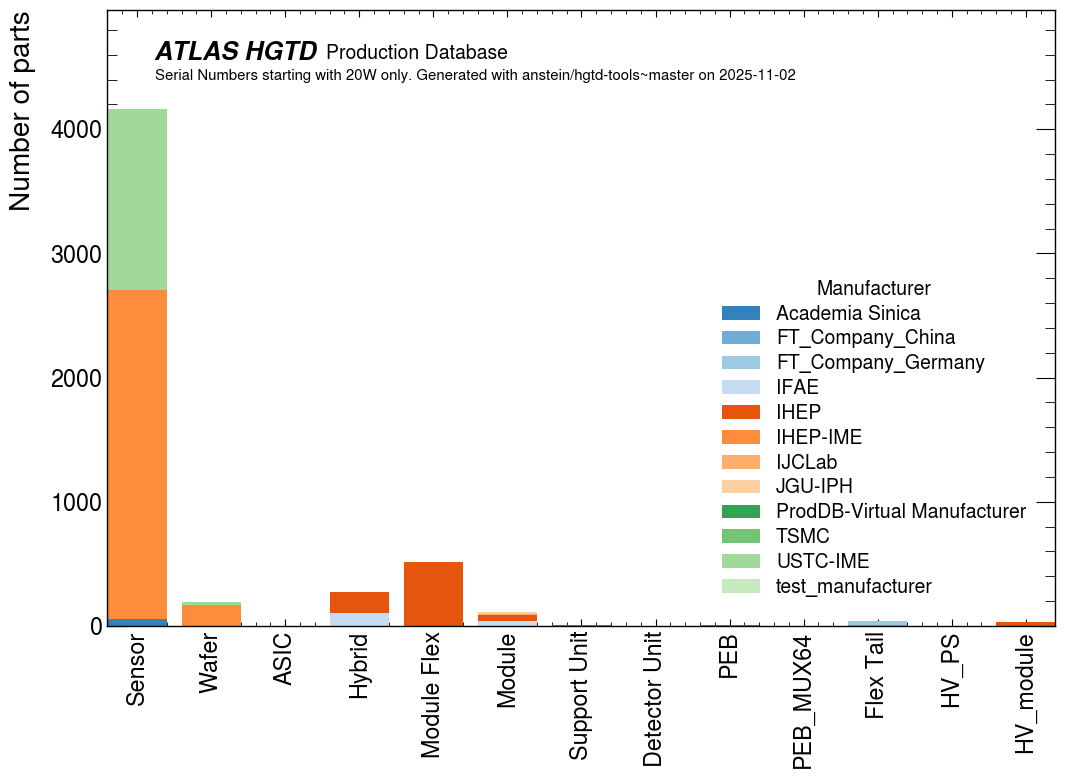

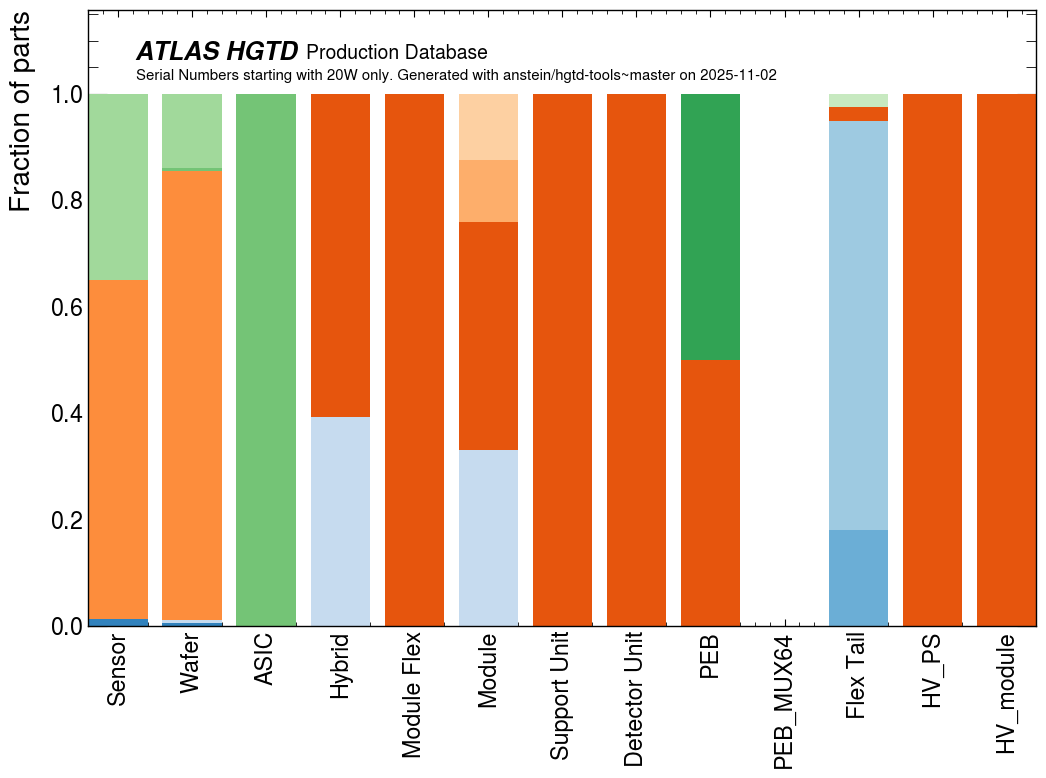

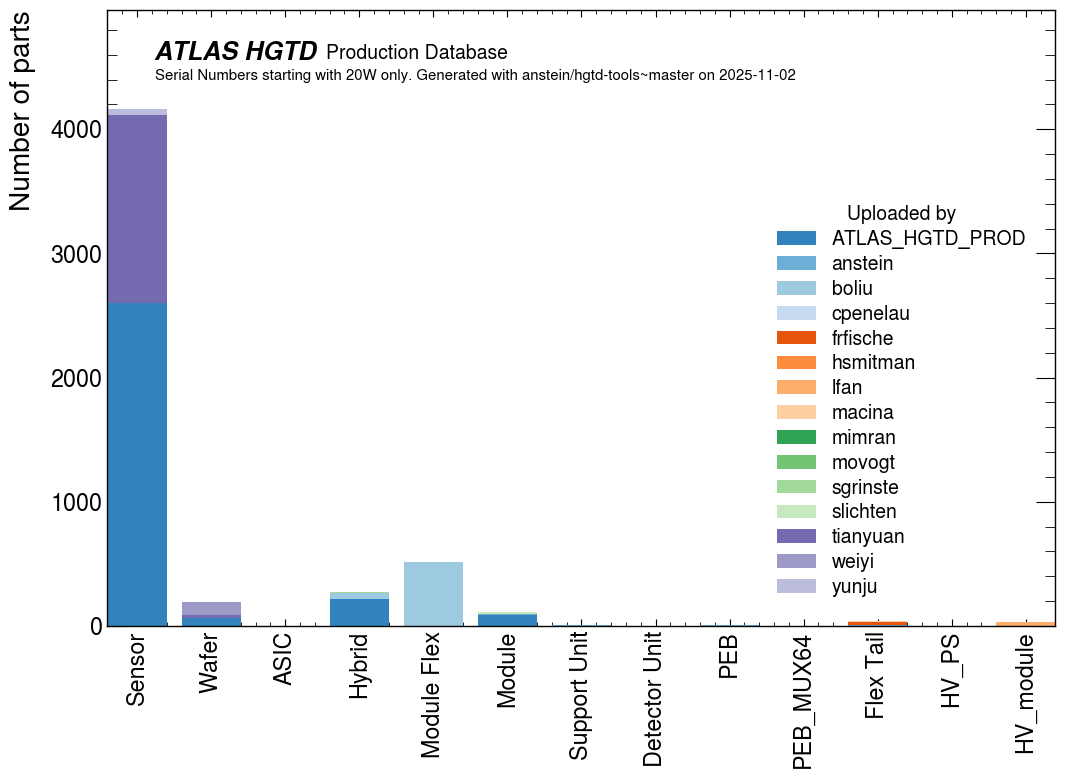

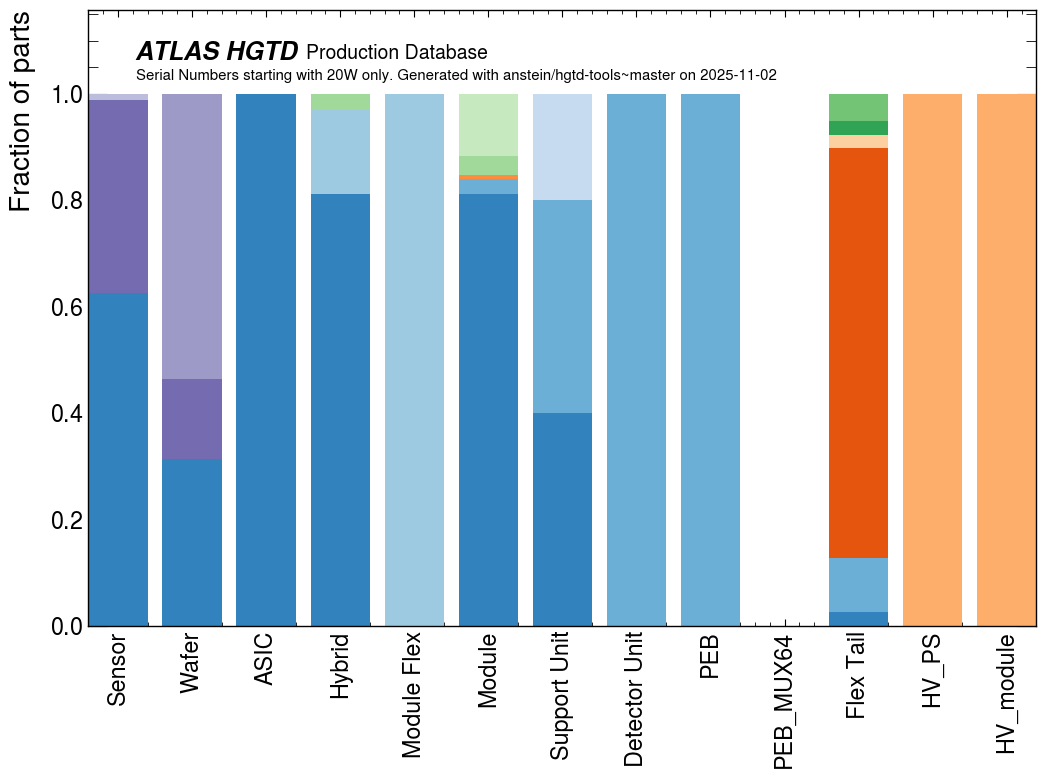

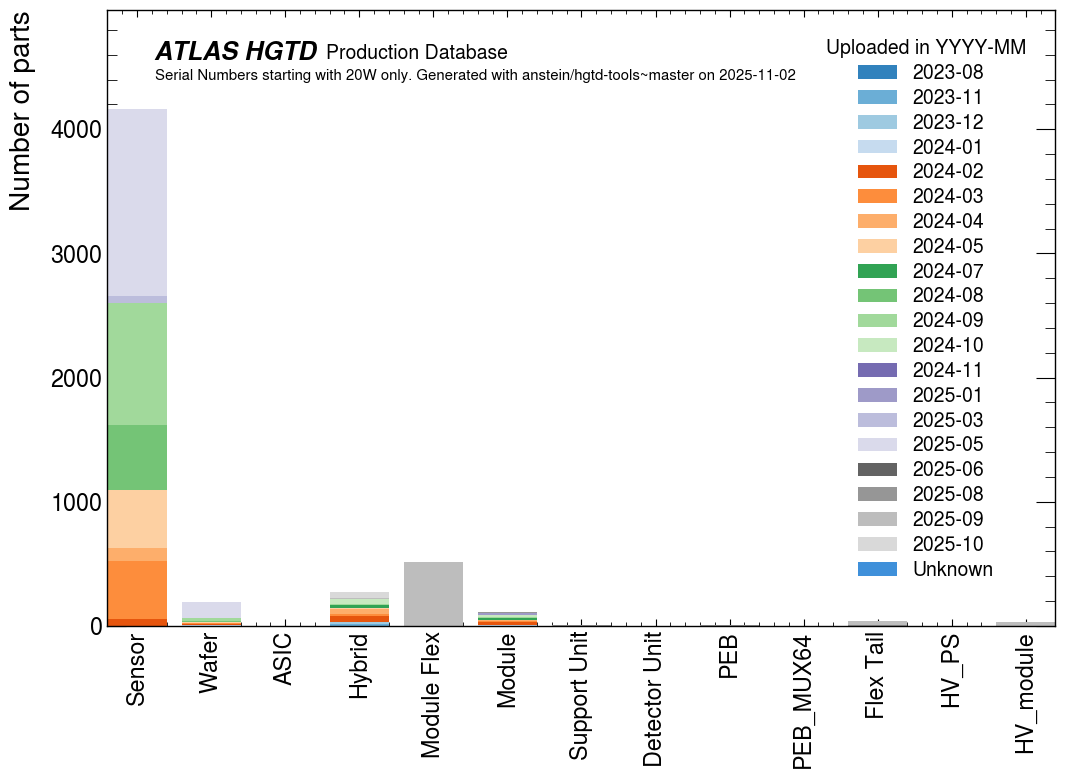

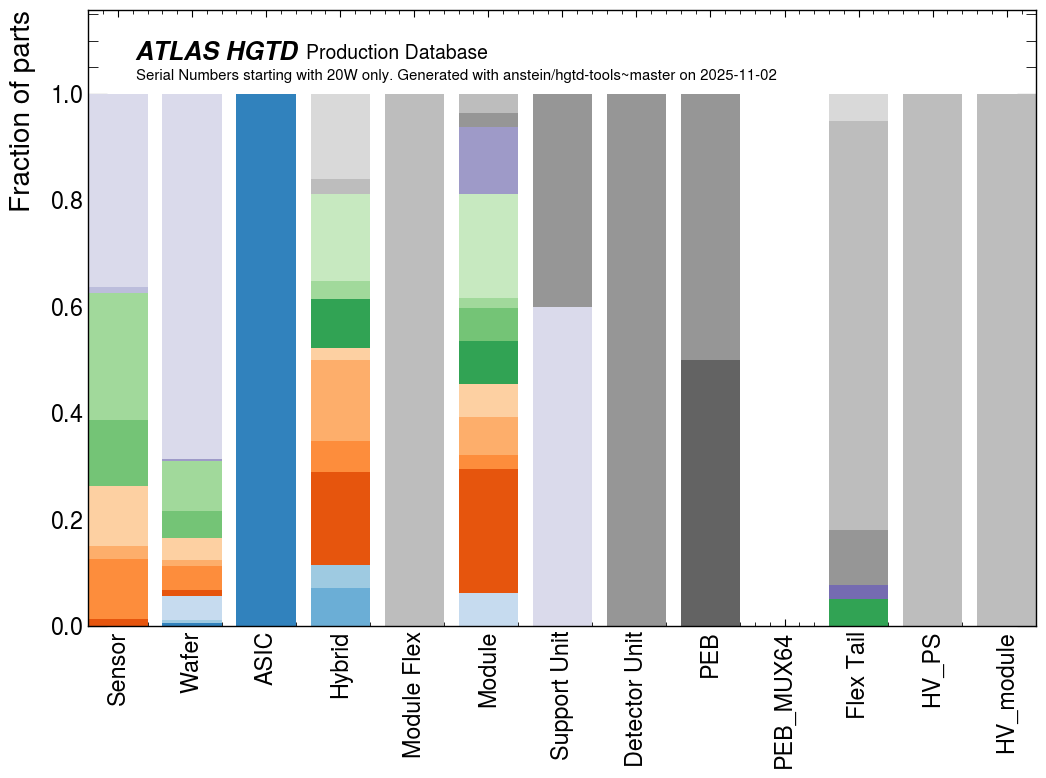

In [103]:
# generate a summary plot

# bars: one per KoP
# colours in stacked histo: attribute value (like manufacturer, location etc.)

for f in interesting_features:
    #if f != 'Manufacturer':
    #    continue
    # merge the legend entries from different categories (i.e. Locations for Sensors, Locations for Modules...)

    all_legend_entries = sorted(list(set(util.flatten([list(multi_count_dict[c][f].keys()) for c in categories]))))
    subcategories = all_legend_entries#['Subcategory 1', 'Subcategory 2', 'Subcategory 3']
    # need to fill the set of possible legend entries with new values (old and fill with 0)
    values = []
    fractions = []
    for c in categories:
        values_list_this_c = []
        fractions_list_this_c = []
        for sc in subcategories:
            if sc in multi_count_dict[c][f].keys():
                values_list_this_c.append(multi_count_dict[c][f][sc])
                fractions_list_this_c.append(multi_count_dict[c][f][sc]/sum(multi_count_dict[c][f].values()))
            else:
                values_list_this_c.append(0)
                fractions_list_this_c.append(0)
        values.append(values_list_this_c)
        fractions.append(fractions_list_this_c)
    values = np.array(values)
    fractions = np.array(fractions)


    # ============


    fig, ax = plt.subplots(figsize=(12,8))
    
    bottom_values = np.zeros(len(categories))
    
    for i, subcategory in enumerate(subcategories):
        ax.bar([i*0.5 for i in range(len(categories))], values[:, i], bottom=bottom_values, label=subcategory, width=0.4)
        bottom_values += values[:, i]
        ax.set_xticks([i*0.5 for i in range(len(categories))], categories)
        
    for tick in ax.get_xticklabels():
        tick.set_rotation(90)
    
    ax.set_ylabel('Number of parts')
    ax.legend(title=f)
    
    hep.label.exp_text("ATLAS HGTD",
                       "Production Database",
                       f"Serial Numbers starting with 20W only. Generated with anstein/hgtd-tools~master on {datetime.today().strftime('%Y-%m-%d')}",
                       loc=4,
                       italic=(True,False,False))
    ax.set_ylim(ax.get_ylim()[0], ax.get_ylim()[-1] * 1.05*1.05)
    plt.show()
    fig.savefig(f'local/counts_{f}.pdf', bbox_inches='tight', facecolor='white', dpi=300)



    # ============

    
    fig, ax = plt.subplots(figsize=(12,8))
    
    bottom_values = np.zeros(len(categories))
    
    for i, subcategory in enumerate(subcategories):
        ax.bar([i*0.5 for i in range(len(categories))], fractions[:, i], bottom=bottom_values, label=subcategory, width=0.4)
        bottom_values += fractions[:, i]
        ax.set_xticks([i*0.5 for i in range(len(categories))], categories)
        
    for tick in ax.get_xticklabels():
        tick.set_rotation(90)
    
    ax.set_ylabel('Fraction of parts')
    #ax.legend(title=f)
    
    hep.label.exp_text("ATLAS HGTD",
                       "Production Database",
                       f"Serial Numbers starting with 20W only. Generated with anstein/hgtd-tools~master on {datetime.today().strftime('%Y-%m-%d')}",
                       loc=4,
                       italic=(True,False,False))
    ax.set_ylim(ax.get_ylim()[0], ax.get_ylim()[-1] * 1.05*1.05*1.05)
    plt.show()
    fig.savefig(f'local/fractions_{f}.pdf', bbox_inches='tight', facecolor='white', dpi=300)

In [69]:
# once happy, convert the above to a script that can run on schedule
# create a gitlab-ci runner for this scheduled action
# write out the results to a place accessible for other users